#### 18.3 滚动条
- 函数 `cv2.createTrackbar(trackbarname, winname, value, count, onChange)` 用来定义滚动条，其中
    - `trackbarname` 为滚动条的名称
    - `winname` 为滚动条所依附窗口的名称
    - `value` 为初始值，决定滚动条中滑块的位置
    - `count` 为滚动条的最大值，通常情况下，最小值是0
    - `onChange` 为回调函数，一般情况下，将滚动条改变后要实现的操作写在该参数对应的回调函数内
- 拖动滚动条，可以设置滚动条的值，可以通过函数 `retval = cv2.getTrackbarPos(trackbarname, winname)` 获取，其中
    - `retval` 为返回值，获取函数 `cv2.createTrackbar()` 生成的滚动条的值
    - `trackbarname` 为滚动条的名称
    - `winname` 为滚动条所依附窗口的名称

##### 1. 实现调色板

In [2]:
import cv2
import numpy as np


def nothing(x):
    pass


img = np.zeros((100, 700, 3), np.uint8)
cv2.namedWindow("Color Panel")
cv2.createTrackbar("R", "Color Panel", 100, 255, nothing)
cv2.createTrackbar("G", "Color Panel", 0, 255, nothing)
cv2.createTrackbar("B", "Color Panel", 0, 255, nothing)

while True:
    r = cv2.getTrackbarPos("R", "Color Panel")
    g = cv2.getTrackbarPos("G", "Color Panel")
    b = cv2.getTrackbarPos("B", "Color Panel")
    img[:] = [b, g, r]
    cv2.imshow("Color Panel", img)
    if cv2.waitKey(10) == 27:
        break

cv2.destroyAllWindows()

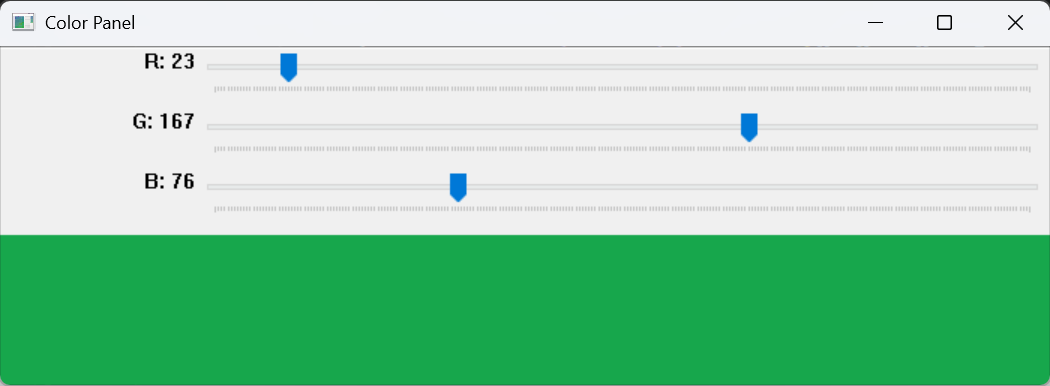

##### 2. 滚动条交互

In [5]:
import cv2
import numpy as np

b = 0
g = 0
r = 0
font = cv2.FONT_HERSHEY_SIMPLEX
img = np.zeros((100, 700, 3), np.uint8)


def changeRed(x):
    global r
    r = cv2.getTrackbarPos("R", "image")
    img[:] = [b, g, r]
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, "Adjust the RED", (0, 70), font, 2, (255, 255, 255), 3)


def changeGreen(x):
    global g
    g = cv2.getTrackbarPos("G", "image")
    img[:] = [b, g, r]
    font = cv2.FONT_HERSHEY_COMPLEX
    cv2.putText(img, "Adjust the GREEN", (0, 70), font, 2, (255, 255, 255), 3)


def changeBlue(x):
    global b
    b = cv2.getTrackbarPos("B", "image")
    img[:] = [b, g, r]
    font = cv2.FONT_HERSHEY_SCRIPT_SIMPLEX
    cv2.putText(img, "Adjust the BLUE", (0, 70), font, 2, (255, 255, 255), 3)


cv2.namedWindow("image")
cv2.createTrackbar("R", "image", 100, 255, changeRed)
cv2.createTrackbar("G", "image", 0, 255, changeGreen)
cv2.createTrackbar("B", "image", 0, 255, changeBlue)
while 1:
    cv2.imshow("image", img)
    k = cv2.waitKey(1) & 0xFF
    if k == 27:
        break
cv2.destroyAllWindows()

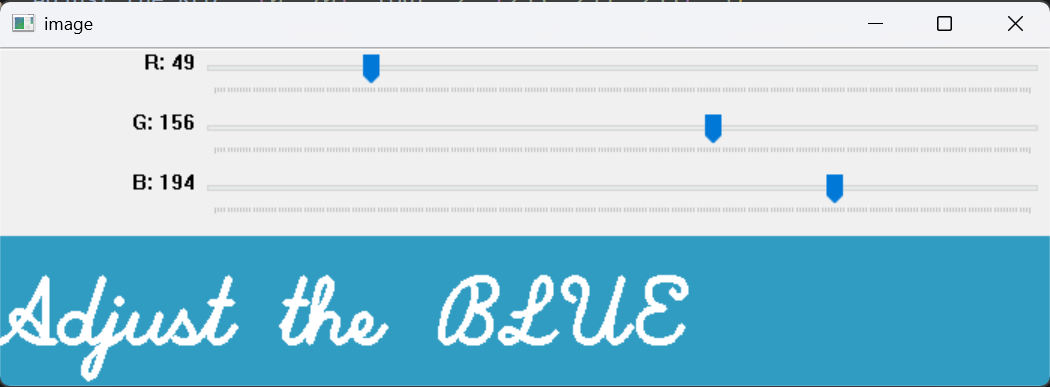

##### 3. 滚动条作为开关

In [6]:
import cv2
import numpy as np

d = 400
global thickness
thickness = -1


def fill(x):
    pass


def draw(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDBLCLK:
        p1x = x
        p1y = y
        p2x = np.random.randint(1, d - 50)
        p2y = np.random.randint(1, d - 50)
        color = np.random.randint(0, high=256, size=(3,)).tolist()
        cv2.rectangle(img, (p1x, p1y), (p2x, p2y), color, thickness)


img = np.ones((d, d, 3), np.uint8) * 255
cv2.namedWindow("image")
cv2.setMouseCallback("image", draw)
cv2.createTrackbar("R", "image", 0, 1, fill)
while 1:
    cv2.imshow("image", img)
    k = cv2.waitKey(1) & 0xFF
    g = cv2.getTrackbarPos("R", "image")
    if g == 0:
        thickness = -1
    else:
        thickness = 2
    if k == 27:
        break
cv2.destroyAllWindows()

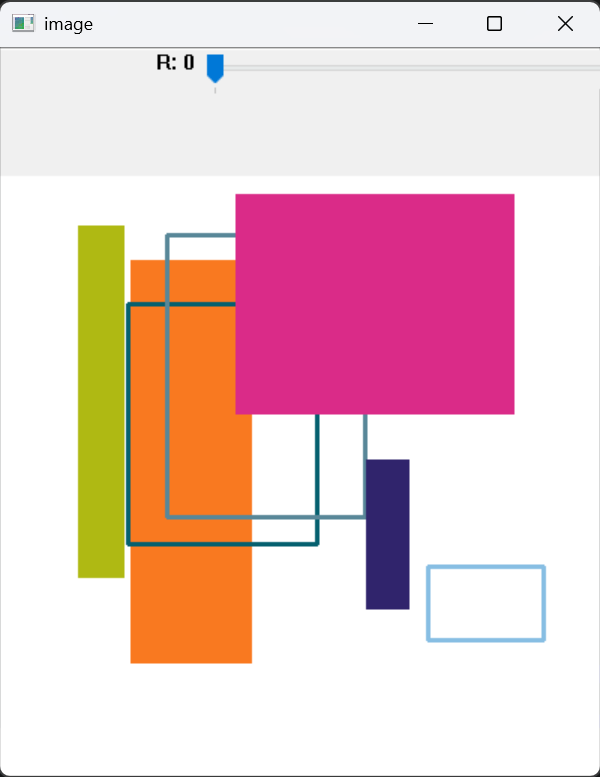